# Week 05: Machine Learning - I

## Understanding Linear Regression through Boston Housing

In [ ]:
# Importing the libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# Importing scikit learn and loading the boston housing dataset

from sklearn.datasets import load_boston
boston = load_boston()

In [ ]:
# Check what the data dictionary has

print(boston.keys())

dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])


In [ ]:
# Describe

print(boston.DESCR)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [ ]:
# Load into Pandas dataframe

df_boston = pd.DataFrame(boston.data)
df_boston.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [ ]:
# Add column names

df_boston.columns = boston.feature_names
df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


Text(0, 0.5, 'Count')

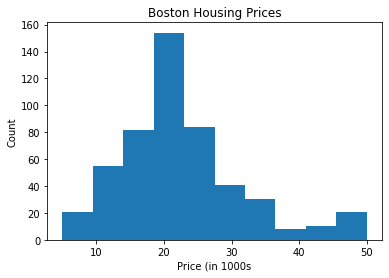

In [ ]:
# Plot to see the housing price variation in $1000

plt.hist(boston.target)
plt.title('Boston Housing Prices')
plt.xlabel('Price (in 1000s)')
plt.ylabel('Count')

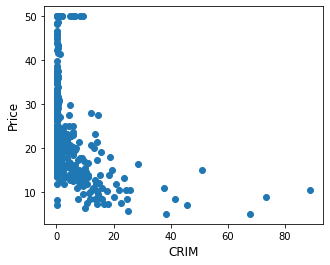

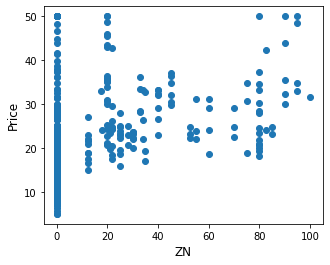

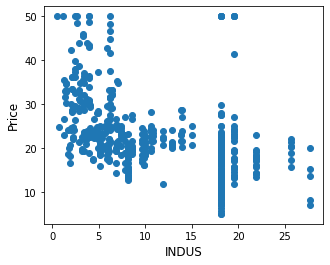

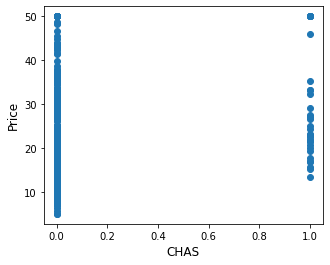

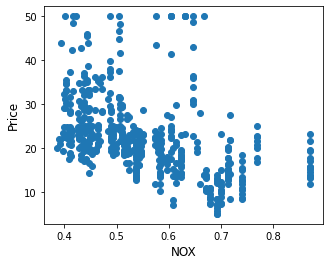

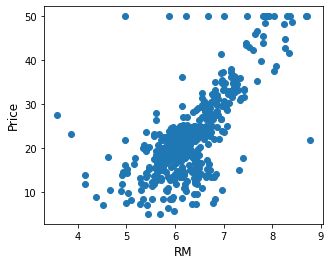

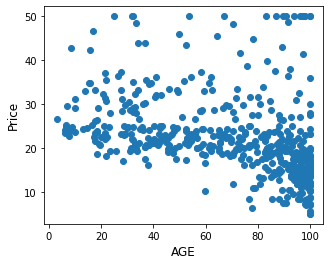

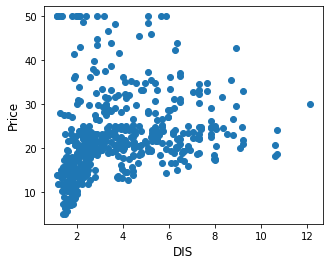

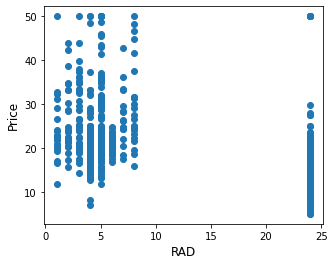

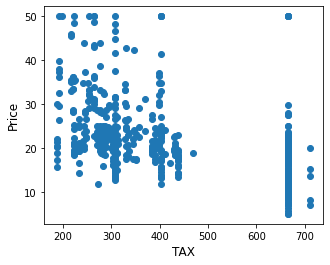

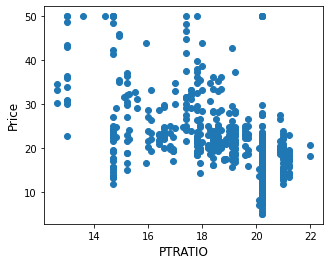

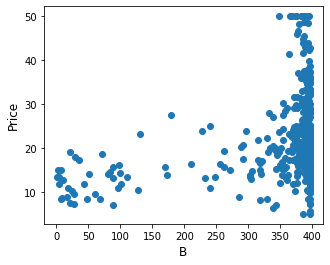

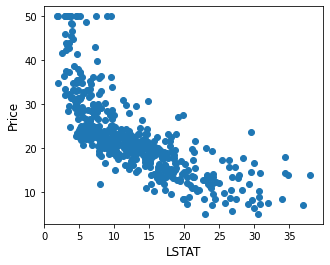

In [ ]:
# A plot for price vs. multiple features

for index, feature_name in enumerate(boston.feature_names):
  plt.figure(figsize=(5, 4))
  plt.scatter(df_boston.iloc[:, index], boston.target)
  plt.ylabel('Price', size=12)
  plt.xlabel(feature_name, size=12)

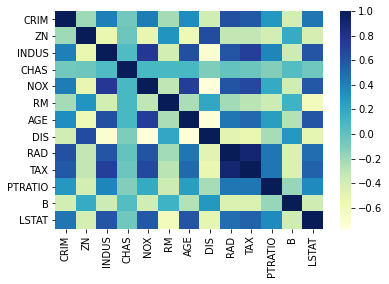

In [ ]:
# Creating a correlation matrix across the features

boston = load_boston()
boston_pd = pd.DataFrame(boston.data, columns=boston.feature_names)
correlation_matrix = boston_pd.corr().round(2)
sns.heatmap(correlation_matrix, cmap='YlGnBu')


In [ ]:
# Size of the target variable

Y = boston.target
print(Y.shape)

(506,)


In [ ]:
# Taking the dataframe as input

X = df_boston

In [ ]:
# Splitting the dataset into training and test data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.42, random_state=7)

In [ ]:
# Checking the size of the test data

y_test.shape

(213,)

In [ ]:
# Creating a regression line

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [ ]:
# Fitting the line over the training values

regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
# Print predictions

y_pred = regressor.predict(X_test)
print(y_pred)

[22.45304419 18.81977601 19.91284374 18.78325718  2.29566881 10.83195471
 20.87778105 29.22806593 29.21883622 13.62543233  5.79480727 33.26735883
 18.4877202  20.58436729 37.59561419 22.86442269 29.46334784 33.50505828
 10.97539144 24.26666433 21.44354015 27.68364768 38.26015936 13.5585175
  8.27083326 15.22309274 36.48572676 26.01486515 25.69035426 27.27226025
 18.4205528  30.87415241 32.02685061 16.19727938 40.2390981  20.62477209
 18.98008612 16.94259545 21.60423547 28.65417564 27.5873761  19.11689102
 14.19065669 26.30472822 17.86311111 13.91417355 24.92473741 18.33045139
 19.3238536   4.98172572 27.55852577 26.88387442 10.31451732 40.37236236
 14.11708175 21.16002536 20.70289588 19.92022118 23.48254639 22.0597531
 20.99264331 35.88146462 17.15647014 20.8726035  23.50320704 44.16503873
 19.07263953 19.56476669 22.35299399 28.10657388 25.85361129 11.96824956
 12.62202792 33.80268291 25.68425547 22.57372681 12.30280395 16.85804725
 28.72612801 17.80026136 24.34675013 27.71125847 22.9

In [ ]:
# Printing the coefficients of the regression lines plotted over

regressor.coef_

array([-1.57786168e-01,  2.66788039e-02, -3.36536736e-02,  2.76770862e+00,
       -1.90734163e+01,  5.67183490e+00, -1.23399288e-02, -1.45531741e+00,
        2.61901460e-01, -9.52295237e-03, -9.62083419e-01,  1.07078406e-02,
       -3.45990995e-01])

In [ ]:
# Printing the intercept value

regressor.intercept_

23.977468009956553

In [ ]:
# Finding R2 score

from sklearn.metrics import r2_score, mean_squared_error

r2_score(y_test,y_pred)

0.6745393322325077

In [ ]:
# Finding MSE

mean_squared_error(y_test, y_pred)

27.822876082245575

In [ ]:
mean_squared_error(y_pred, y_test)

25.76787949083653

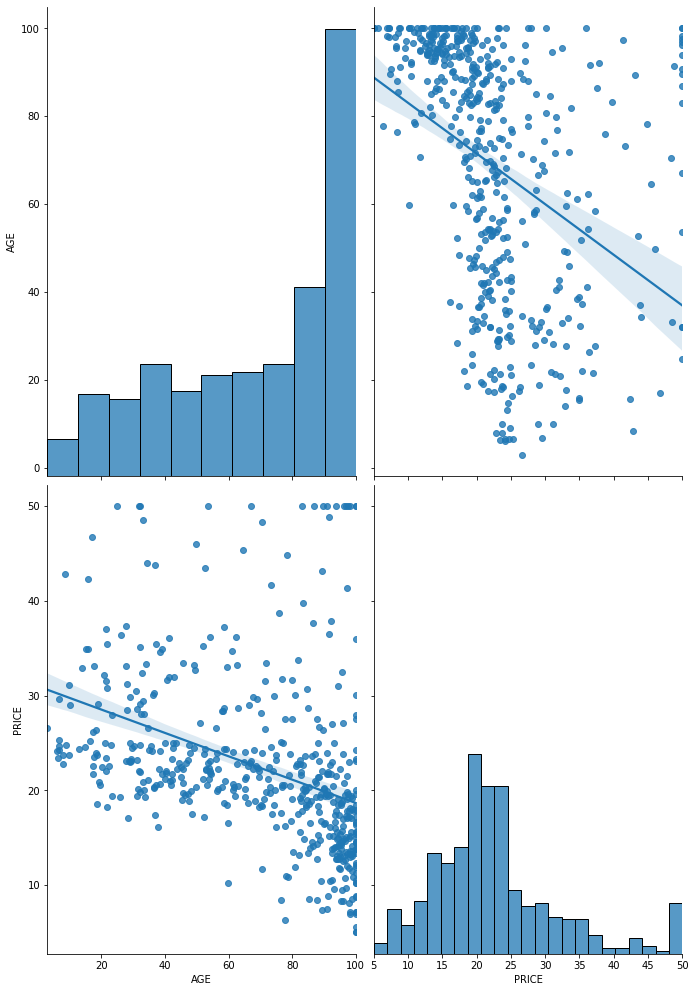

In [ ]:
# Relation between the price and age with the regression line

plot_df = df_boston.copy()
plot_df['PRICE'] = boston.target

sns.pairplot(plot_df, vars=['AGE', 'PRICE'], height=7, aspect=0.7, kind='reg')

In [ ]:
# Regression score

regressor.score(X_test, y_test)

0.6702986299596931